In [1]:
import kagglehub
import pandas as pd
import numpy as np
import os


try:
    path = kagglehub.dataset_download("chethuhn/network-intrusion-dataset")
    data = pd.read_csv(os.path.join(path, 'Wednesday-workingHours.pcap_ISCX.csv' ))
    print('Wednesday data confirmed. :)')

except Exception as e:
    print(f'Something went wrong {e}')

data.head()

Wednesday data confirmed. :)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,38308,1,1,6,6,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,389,479,11,5,172,326,79,0,15.636364,31.449238,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,88,1095,10,6,3150,3150,1575,0,315.000000,632.561635,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,389,15206,17,12,3452,6660,1313,0,203.058823,425.778474,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,88,1092,9,6,3150,3152,1575,0,350.000000,694.509719,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [2]:
data.columns = data.columns.str.strip()

print(data.shape)

print(data.dtypes)

(692703, 79)
Destination Port                 int64
Flow Duration                    int64
Total Fwd Packets                int64
Total Backward Packets           int64
Total Length of Fwd Packets      int64
                                ...   
Idle Mean                      float64
Idle Std                       float64
Idle Max                         int64
Idle Min                         int64
Label                           object
Length: 79, dtype: object


In [3]:
print(data.isnull().sum())
print('----')
print(data['Label'].value_counts())

num_port = {}
count = {}

for label, port in zip(data['Label'], data['Destination Port']):
    if label not in num_port:
        num_port[label] = []
    num_port[label].append(port)

for label, ports in num_port.items():
    count = {}
    for port in ports:
        if port not in count:
            count[port] = 0
        count[port] += 1
    most_common_port = max(count, key=count.get)
    least_common_port = min(count, key=count.get)
    other_ports = [port for port, hits in count.items() if port not in [most_common_port, least_common_port]]
    print(f"Label: {label}, Most Common Destination Port: {most_common_port}, Hits: {count[most_common_port]}")
    print(f"Label: {label}, Least Common Destination Port: {least_common_port}, Hits: {count[least_common_port]}")
    print(f"Label: {label}, Other Destination Ports: {other_ports}")
    print("-----")

Destination Port               0
Flow Duration                  0
Total Fwd Packets              0
Total Backward Packets         0
Total Length of Fwd Packets    0
                              ..
Idle Mean                      0
Idle Std                       0
Idle Max                       0
Idle Min                       0
Label                          0
Length: 79, dtype: int64
----
Label
BENIGN              440031
DoS Hulk            231073
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Heartbleed              11
Name: count, dtype: int64
Label: BENIGN, Most Common Destination Port: 53, Hits: 195531
Label: BENIGN, Least Common Destination Port: 13792, Hits: 1
Label: BENIGN, Other Destination Ports: [80, 389, 88, 49666, 49413, 3268, 443, 135, 49441, 44459, 21, 13791, 22, 465, 35215, 40372, 45392, 49461, 42064, 49483, 49489, 13810, 5353, 123, 0, 445, 49469, 49471, 49528, 138, 49548, 49671, 49194, 8612, 8610, 139, 49512, 13797, 13800, 49229, 49231

In [4]:
from sklearn.preprocessing import LabelEncoder


le = LabelEncoder()

columns_drop = [
    'Fwd Header Length.1'
]

print(data[data['Label'] == 'Heartbleed'].describe())
data['Label'] = le.fit_transform(data['Label'])

data.replace([np.inf, -np.inf], np.nan, inplace= True )
data.dropna(inplace = True)

data = data.drop(columns=columns_drop, errors='ignore')

X = data.drop('Label', axis=1)
y = data['Label']



       Destination Port  Flow Duration  Total Fwd Packets  \
count              11.0   1.100000e+01          11.000000   
mean              444.0   1.106797e+08        2583.727273   
std                 0.0   2.850973e+07         662.093663   
min               444.0   2.471967e+07         590.000000   
25%               444.0   1.192594e+08        2782.000000   
50%               444.0   1.192611e+08        2792.000000   
75%               444.0   1.192973e+08        2799.000000   
max               444.0   1.193027e+08        2805.000000   

       Total Backward Packets  Total Length of Fwd Packets  \
count               11.000000                    11.000000   
mean              1897.181818                 12509.727273   
std                497.143605                  3590.810162   
min                436.000000                  7442.000000   
25%               2017.000000                 10816.000000   
50%               2069.000000                 12264.000000   
75%             

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=1)

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

model = RandomForestClassifier(n_estimators= 100, random_state=1 )

model.fit(X_train, y_train)
pred = model.predict(X_test)

print(classification_report(y_test, pred))




              precision    recall  f1-score   support

           0       1.00      1.00      1.00     88152
           1       1.00      0.99      1.00      2075
           2       1.00      1.00      1.00     45829
           3       1.00      0.99      1.00      1109
           4       0.99      1.00      0.99      1115
           5       1.00      1.00      1.00         2

    accuracy                           1.00    138282
   macro avg       1.00      1.00      1.00    138282
weighted avg       1.00      1.00      1.00    138282



Bwd Packet Length Mean    0.064629
Packet Length Std         0.052732
Subflow Bwd Bytes         0.052654
Bwd Packet Length Std     0.049441
Average Packet Size       0.049314
Avg Bwd Segment Size      0.046764
Packet Length Mean        0.043080
Bwd Packets/s             0.039732
Max Packet Length         0.037540
Destination Port          0.035775
dtype: float64


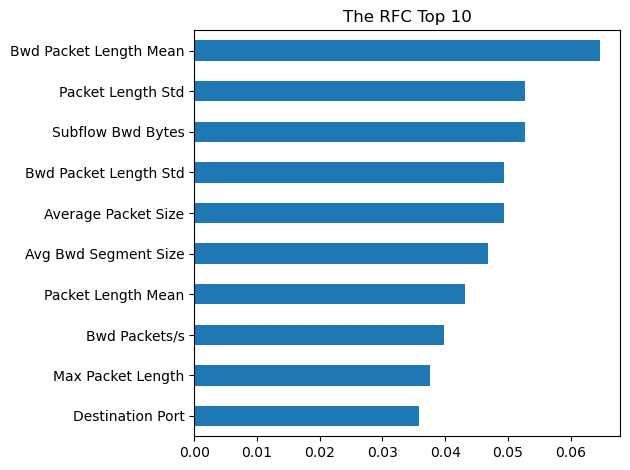

In [7]:
import matplotlib.pyplot as plt

rfc_importance = RandomForestClassifier(n_estimators = 100, random_state=1)
rfc_importance.fit(X,y)

importance = pd.Series(rfc_importance.feature_importances_, index=X.columns)
print(importance.nlargest(10))

importance.nlargest(10).sort_values().plot(kind='barh')
plt.title('The RFC Top 10')
plt.tight_layout()
plt.show()